# Trip Advisor NLP - Natural Language Processing

The primary objective of this project is to build an end-to-end Deep Learning framework for binary sentiment classification in the hospitality industry. Utilizing an extreme-polarity dataset of 1-star and 5-star hotel reviews, the project executes a full machine learning pipeline—from text preprocessing and tokenization to model training with an Artificial Neural Network (ANN). The goal is to capture complex contextual nuances in customer feedback, providing an automated and scalable solution for auditing brand sentiment and guest satisfaction.

<img src='https://ps.w.org/review-widgets-for-tripadvisor/assets/icon-256x256.png?rev=2816270' width='750'>

In [1]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download required NLTK data (punkt_tab added)
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize objects and variables
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
rare_words = set()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\furka\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# EDA

In [2]:
df=pd.read_csv('tripadvisor_hotel_reviews.csv')

In [3]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [4]:
df.tail()

,Review,Rating
20486,"best kept secret 3rd time staying charm, not 5...",5
20487,great location price view hotel great quick pl...,4
20488,"ok just looks nice modern outside, desk staff ...",2
20489,hotel theft ruined vacation hotel opened sept ...,1
20490,"people talking, ca n't believe excellent ratin...",2


In [5]:
df.shape

(20491, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [7]:
df.isnull().sum()

Review    0
Rating    0
dtype: int64

In [8]:
df['Review'][77]

'single rooms like hospital rooms single rooms hotel sparse intentional know ugly like trapped hospital white walls sink basin room small rectangle shape.the beds hard rocks blankets rough really noisy.this overrated hotel stayed fan stype hotels,  '

Read dataset

Convert text to lowercase

Remove punctuation

Remove numbers / digits

Remove newlines and carriage returns

Remove stop words

Tokenize text

Perform stemming / lemmatization

Vectorize text

Apply TF-IDF (Term Frequency - Inverse Document Frequency)

In [9]:
df['Review'] = df['Review'].str.lower() # convert text to lowercase
df['Review'] = df['Review'].str.replace('http\S+|www\S+', '', regex=True) # remove urls
df['Review'] = df['Review'].str.replace('[^\w\s]', '', regex=True) # remove punctuation
df['Review'] = df['Review'].str.replace('\d+', '', regex=True) # remove numbers / digits
df['Review'] = df['Review'].str.replace('\r', '', regex=True) # remove carriage returns
df['Review'] = df['Review'].str.replace('\n', '', regex=True) # remove newlines
df['Review'] = df['Review'].str.replace('\s+', ' ', regex=True).str.strip() # remove extra whitespaces
df['Review'] = df['Review'].apply(word_tokenize) # tokenize text
df['Review'] = df['Review'].apply(lambda x: [w for w in x if w not in stop_words]) # remove stop words
df['Review'] = df['Review'].apply(lambda x: [w for w in x if w not in rare_words]) # remove rare words
df['Review'] = df['Review'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x]) # perform lemmatization
df['Review'] = df['Review'].apply(lambda x: ' '.join(x)) # join tokens to string

In [10]:
df['Review'][66]

'loved inn husband wanted romantic away night inn perfect met imagined room clean quiet comfortable bath robe nice touch staff helpful location great good restaurant walking distance market right fun visit time free bus service close visit site city beware parking hotel valet cost night mentioned desk person away cost mentioned web page expected pay removed charge great customer service wonderful deck overlooking puget sound recommend inn planning long visit romantic away'

### Sentiment Analysis

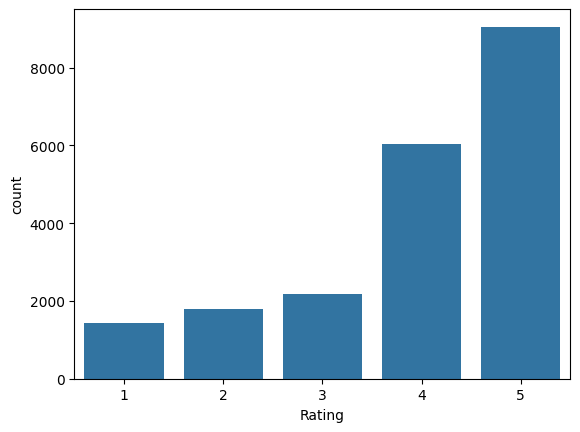

In [11]:
sns.countplot(x=df['Rating']);

In [12]:
tabw=df[(df.Rating==1)| (df.Rating==5)] #Trip Advisor Best & Worst

In [13]:
tabw.reset_index(drop=True,inplace=True) 

In [14]:
x=tabw[['Review']]
y=tabw[['Rating']]

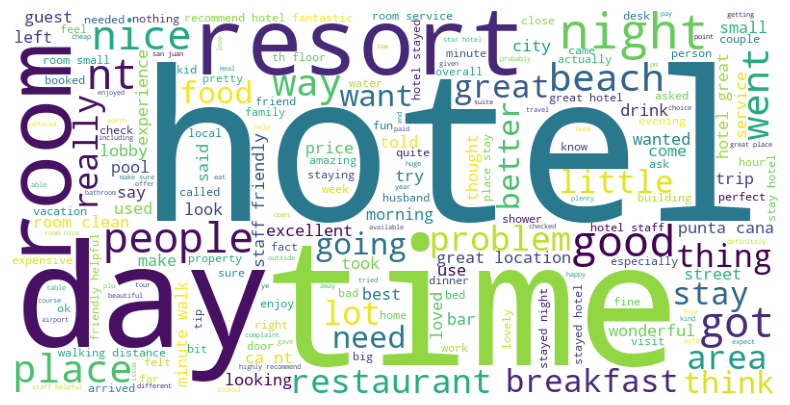

In [15]:
from wordcloud import WordCloud

text = ' '.join(df['Review'].dropna())
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [16]:
from collections import Counter

# Combine all review texts into one long string and then split into individual words
all_words = ' '.join(df['Review']).split()
data = Counter(all_words).most_common(20)

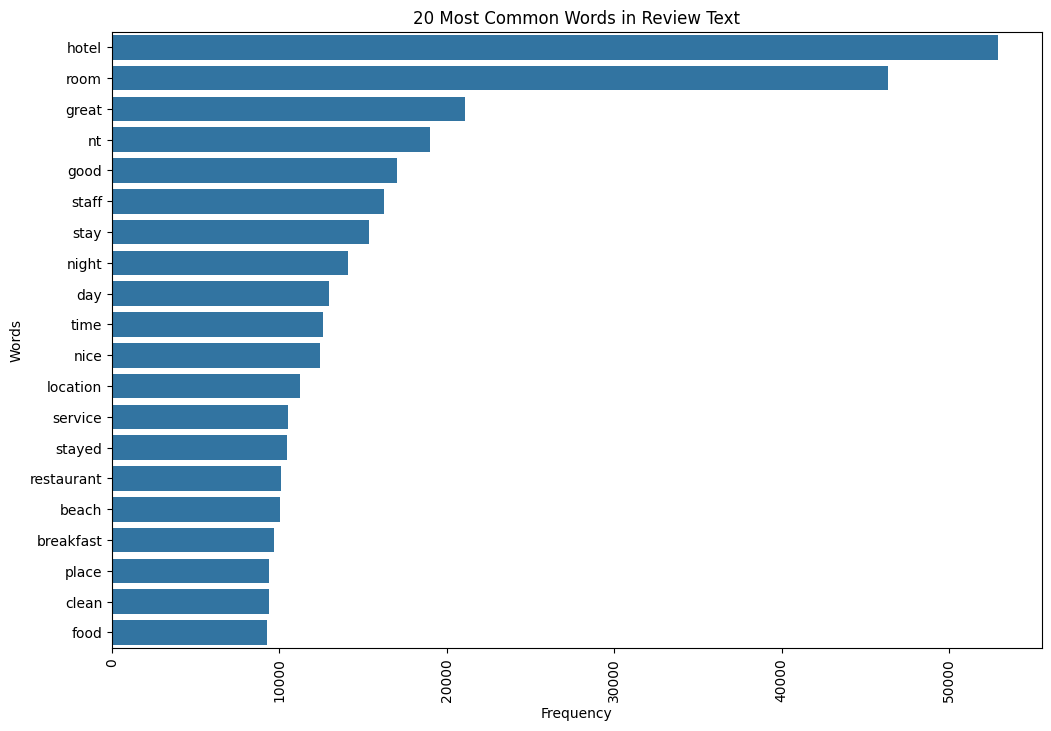

In [17]:
common_words_df = pd.DataFrame(data, columns=['word', 'count'])

plt.figure(figsize=(12,8))
sns.barplot(x='count', y='word', data=common_words_df)
plt.title('20 Most Common Words in Review Text')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.xticks(rotation=90);
plt.show()

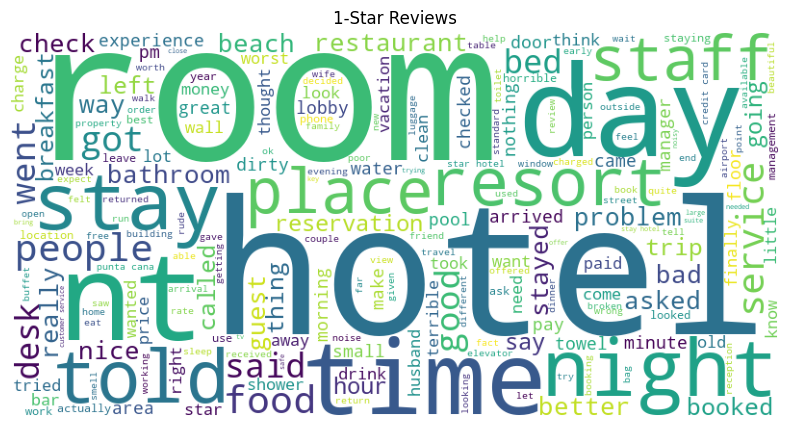

In [18]:
wc1 = WordCloud(width=800, height=400, background_color='white').generate(
    ' '.join(df[df['Rating'] == 1]['Review'].dropna())
)
plt.figure(figsize=(10, 5))
plt.imshow(wc1)
plt.axis('off')
plt.title('1-Star Reviews')
plt.show()

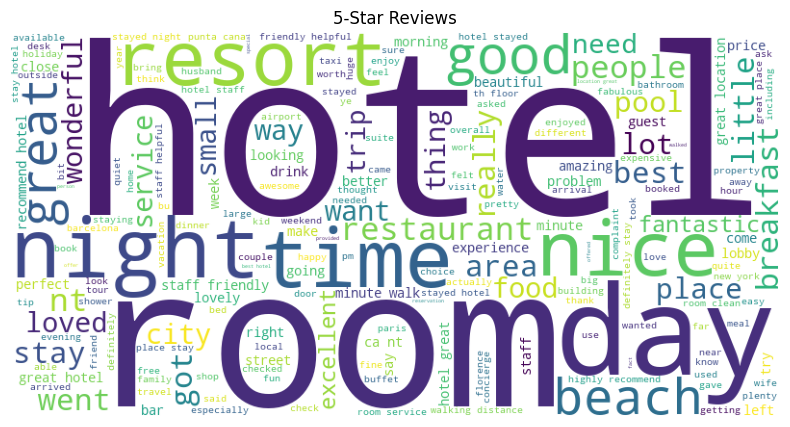

In [19]:
wc5 = WordCloud(width=800, height=400, background_color='white').generate(
    ' '.join(df[df['Rating'] == 5]['Review'].dropna())
)
plt.figure(figsize=(10, 5))
plt.imshow(wc5)
plt.axis('off')
plt.title('5-Star Reviews')
plt.show()

### Modeling

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words='english', ngram_range=(1,2), max_features=5000)
x_vect = vec.fit_transform(tabw['Review']).toarray()

In [21]:
tabw = df[(df.Rating == 1) | (df.Rating == 5)].copy()
tabw['Rating'] = tabw['Rating'].map({1: 0, 5: 1})
y = tabw['Rating'].values

In [22]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_vect, y, random_state=42, test_size=0.2)

In [24]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [25]:
model = Sequential([Input(shape=(x_train.shape[1],)),Dense(128, activation='relu'),Dropout(0.2),Dense(64, activation='relu'),Dense(1, activation='sigmoid')])

In [26]:
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [27]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(x_train, y_train,batch_size=32,validation_split=0.1,callbacks=[early_stop],verbose=2,epochs=15)

Epoch 1/15
236/236 - 3s - 11ms/step - accuracy: 0.9517 - loss: 0.1252 - val_accuracy: 0.9821 - val_loss: 0.0480
Epoch 2/15
236/236 - 2s - 7ms/step - accuracy: 0.9962 - loss: 0.0150 - val_accuracy: 0.9726 - val_loss: 0.1039
Epoch 3/15
236/236 - 2s - 7ms/step - accuracy: 0.9984 - loss: 0.0067 - val_accuracy: 0.9642 - val_loss: 0.1983
Epoch 4/15
236/236 - 2s - 7ms/step - accuracy: 0.9987 - loss: 0.0058 - val_accuracy: 0.9809 - val_loss: 0.0821


In [29]:
model.evaluate(x_test,y_test)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9804 - loss: 0.0606


[0.06059419736266136, 0.9804295897483826]

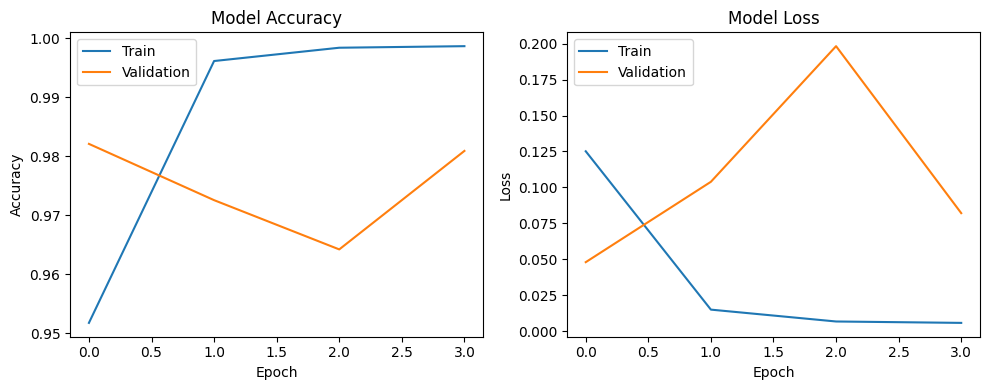

In [30]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = (model.predict(x_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       289
           1       0.99      0.99      0.99      1806

    accuracy                           0.98      2095
   macro avg       0.96      0.96      0.96      2095
weighted avg       0.98      0.98      0.98      2095

[[ 270   19]
 [  22 1784]]


## Conclusion

We built a neural network that classifies reviews as Positive or Negative from their text, using a bag-of-words representation with n-grams. The model reached a test accuracy of 98% and a macro F1-score of 0.96, exceeding the 95% target. Although the dataset is imbalanced (about 86% positive), the model performs well on both classes: F1 = 0.99 for Positive and F1 = 0.93 for Negative. Of the 2,095 test reviews, only 41 were misclassified (19 negative reviews predicted as positive and 22 positive reviews predicted as negative), so errors are balanced across the two classes.

Overfitting was controlled with Dropout, a low learning rate, and EarlyStopping (restore_best_weights=True), which stopped training after only a few epohs. The test set was kept separate from validation, and the vectorizer was fitted only on the training data, so the reported scores are unbiased.